In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# creating the data
data = {
    'trip_date':['2026-03-01','2026-03-02','2026-03-03','2026-03-04','2026-03-05','2026-03-06','2026-03-07','2026-03-08','2026-03-09','2026-03-10'],
    'total_fares':[280.00, 320.00, 150.00, 400.00, 500.00, 450.00, 600.00, 700.00, 300.00, 200.00],
    'fuel_cost':[80.00, 90.00, 70.00, 95.00, 100.00, 95.00, 60.00, 85.00, 105.00, 90.00],
    'trips_completed':[12, 14, 7, 16, 12, 8, 9, 10, 11, 13]
}
# Create DataFrame
df = pd.DataFrame(data)
print("Dataset:")
df

Dataset:


,trip_date,total_fares,fuel_cost,trips_completed
0,2026-03-01,280.0,80.0,12
1,2026-03-02,320.0,90.0,14
2,2026-03-03,150.0,70.0,7
3,2026-03-04,400.0,95.0,16
4,2026-03-05,500.0,100.0,12
5,2026-03-06,450.0,95.0,8
6,2026-03-07,600.0,60.0,9
7,2026-03-08,700.0,85.0,10
8,2026-03-09,300.0,105.0,11
9,2026-03-10,200.0,90.0,13


   UNIT 1 -- Python Basics

In [33]:
# 1. Store a daily earnings target in a variable
daily_target = 200.00

# 3. Use a for loop to calculate net earnings for a sample list of days

sample_fares = [280.00, 320.00, 150.00, 400.00]
sample_fuel = [80.00, 90.00, 70.00, 95.00]


for i in range(len(sample_fares)):
    net_earning = sample_fares[i] - sample_fuel[i]
    
    # 2. Use if/else to check whether a day's net earnings met the target
    if net_earning >= daily_target:
        status = "Met Target"
    else:
        status = "Missed Target"
        
    print(f"Day {i+1}: Net Earnings = GHS {net_earning:.2f} -> {status}")

Day 1: Net Earnings = GHS 200.00 -> Met Target
Day 2: Net Earnings = GHS 230.00 -> Met Target
Day 3: Net Earnings = GHS 80.00 -> Missed Target
Day 4: Net Earnings = GHS 305.00 -> Met Target


 UNIT 2 -- Functions and Lambda Expressions

In [2]:
# 1. Write a function net_earnings(total_fares, fuel_cost)
def net_earnings(total_fares, fuel_cost):
    return total_fares - fuel_cost

# 2. Write a function average_fare_per_trip(total_fares, trips_completed)
def average_fare_per_trip(total_fares, trips_completed):
    return total_fares / trips_completed 
    
# 3. Use a lambda to flag days where fuel cost exceeds 30% of total fares as 'High Fuel Day'
# If fuel_cost / total_fares > 0.30, flag it, otherwise mark 'Normal'
flag_high_fuel = lambda total, fuel: 'High Fuel Day' if (fuel / total) > 0.30 else 'Normal'

fares = 280.00
fuel = 80.00
trips = 12

earnings = net_earnings(fares, fuel)
avg_fare = average_fare_per_trip(fares, trips)
fuel_status = flag_high_fuel(fares, fuel)

# Print the outputs
print(f"Total Earnings: ${earnings:.2f}")
print(f"Average Fare per Trip: ${avg_fare:.2f}")
print(f"Fuel Cost Status: {fuel_status}")



Total Earnings: $200.00
Average Fare per Trip: $23.33
Fuel Cost Status: Normal


UNIT 3 --- PANDAS

In [31]:
# 1. Load the dataset and create 'net_earnings' and 'fare_per_trip' columns
df['net_earnings'] = net_earnings(df['total_fares'], df['fuel_cost'])
df['fare_per_trip'] = average_fare_per_trip(df['total_fares'], df['trips_completed'])

# Apply the lambda expression to create the fuel flag column
df['fuel_flag'] = df.apply(lambda row: flag_high_fuel(row['total_fares'], row['fuel_cost']), axis=1)

# 2. Use df.sort_values('trip_date') to order data chronologically
df = df.sort_values('trip_date')

# 3. Use df['net_earnings'].sum() to calculate total earnings for the period
total_period_earnings = df['net_earnings'].sum()

print(f"Total Net Earnings for the period: GHS {total_period_earnings:.2f}\n")
#print("Processed DataFrame:")



# 4. Filter days flagged as 'High Fuel Day' to review fuel efficiency
high_fuel_days = df[df['fuel_flag'] == 'High Fuel Day']
print(high_fuel_days)
df

Total Net Earnings for the period: GHS 3030.00

    trip_date  total_fares  fuel_cost  trips_completed  net_earnings  \
2  2026-03-03        150.0       70.0                7          80.0   
8  2026-03-09        300.0      105.0               11         195.0   
9  2026-03-10        200.0       90.0               13         110.0   

   fare_per_trip      fuel_flag  
2      21.428571  High Fuel Day  
8      27.272727  High Fuel Day  
9      15.384615  High Fuel Day  


,trip_date,total_fares,fuel_cost,trips_completed,net_earnings,fare_per_trip,fuel_flag
0,2026-03-01,280.0,80.0,12,200.0,23.333333,Normal
1,2026-03-02,320.0,90.0,14,230.0,22.857143,Normal
2,2026-03-03,150.0,70.0,7,80.0,21.428571,High Fuel Day
3,2026-03-04,400.0,95.0,16,305.0,25.000000,Normal
4,2026-03-05,500.0,100.0,12,400.0,41.666667,Normal
5,2026-03-06,450.0,95.0,8,355.0,56.250000,Normal
6,2026-03-07,600.0,60.0,9,540.0,66.666667,Normal
7,2026-03-08,700.0,85.0,10,615.0,70.000000,Normal
8,2026-03-09,300.0,105.0,11,195.0,27.272727,High Fuel Day
9,2026-03-10,200.0,90.0,13,110.0,15.384615,High Fuel Day


In [ ]:
# 1. Convert net_earnings to a NumPy array
net_earnings_array = df['net_earnings'].to_numpy()

# 2. Calculate average daily net earnings using np.mean()
avg_net_earnings = np.mean(net_earnings_array)

# 3. Use np.min() and np.argmin() to find the worst earning day and its index
worst_earning_value = np.min(net_earnings_array)
worst_earning_index = np.argmin(net_earnings_array)
worst_earning_date = df.loc[worst_earning_index, 'trip_date']


print(f"Average Daily Net Earnings: GHS {avg_net_earnings:.2f}")
print(f"Worst Earning Day Index: {worst_earning_index}")
print(f"Worst Earning Day Value: GHS {worst_earning_value:.2f} on {worst_earning_date}")

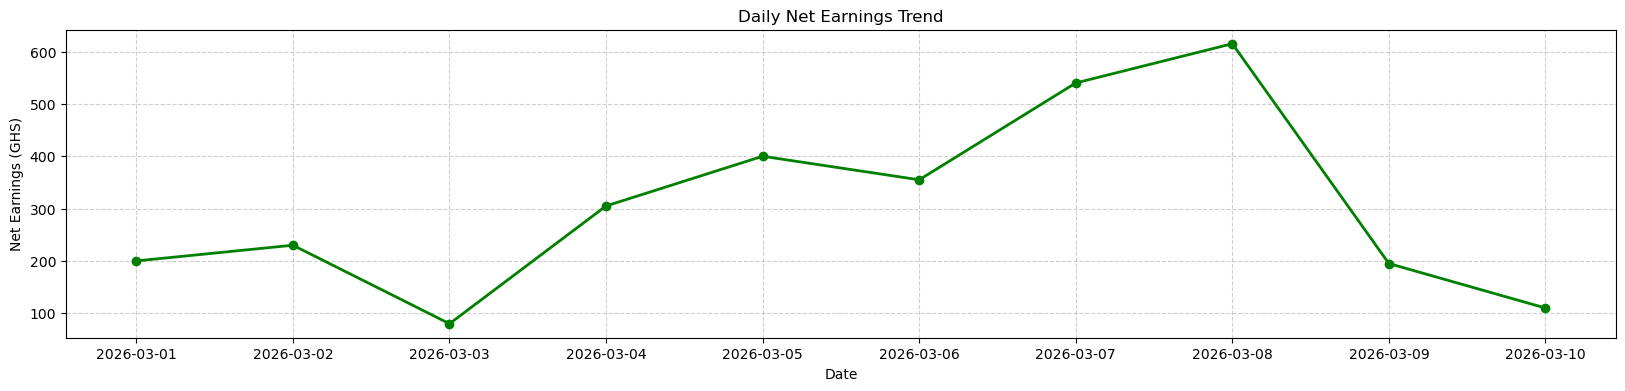

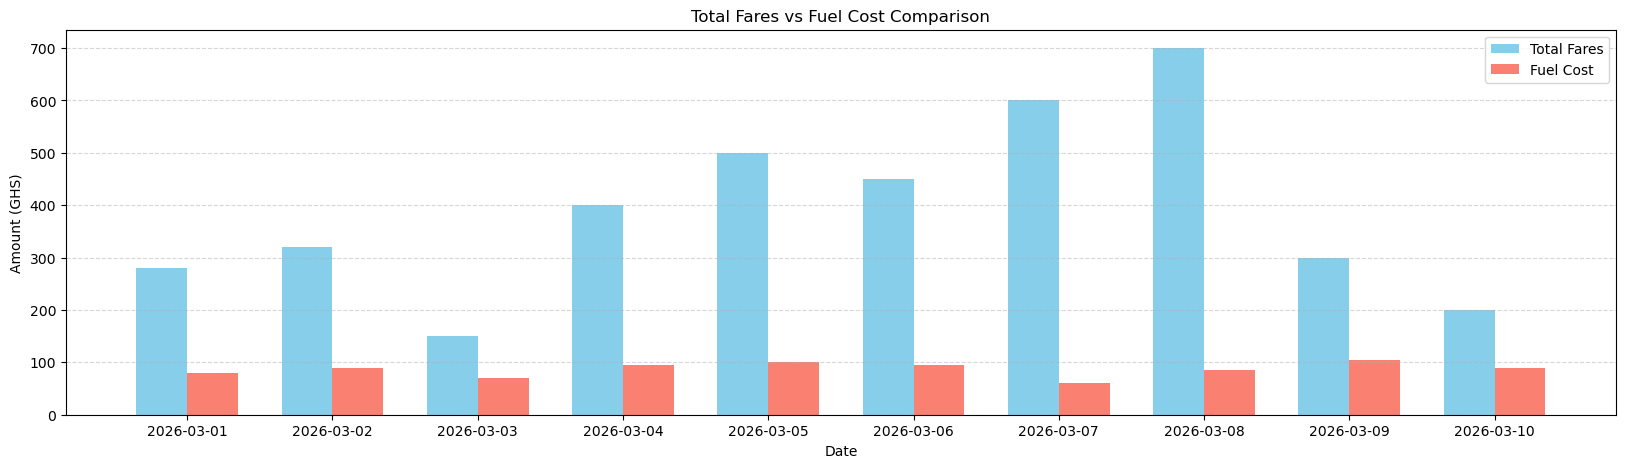

In [16]:
# 1 & 2. Plot a line chart of net earnings over the month with appropriate labels
plt.figure(figsize=(20, 4))
plt.plot(df['trip_date'], df['net_earnings'], marker='o', color='green', linewidth=2)

plt.title('Daily Net Earnings Trend')
plt.xlabel('Date')
plt.ylabel('Net Earnings (GHS)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Create a bar chart comparing total fares vs fuel cost per day


plt.figure(figsize=(20, 5))
plt.bar(x - width/2, df['total_fares'], width, label='Total Fares', color='skyblue')
plt.bar(x + width/2, df['fuel_cost'], width, label='Fuel Cost', color='salmon')

plt.title('Total Fares vs Fuel Cost Comparison')
plt.xlabel('Date')
plt.ylabel('Amount (GHS)')
plt.xticks(x, df['trip_date'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()